In [ ]:
import findspark
findspark.init()
from pyspark.sql import SparkSession
spark=SparkSession.builder\
    .appName('SparkToOracle')\
    .config('spark.jars','E:\workspace\python_script\.venv\Lib\site-packages\pyspark\jars\ojdbc6.jar')\
    .config("spark.driver.extraClassPath", "E:\workspace\python_script\.venv\Lib\site-packages\pyspark\jars\ojdbc6.jar") \
    .getOrCreate()
# 连接信息（你本地的PostgreSQL）
# jdbc:oracle:thin:@//IP:端口/服务名
url = 'jdbc:oracle:thin:@localhost:1521/ORCL'

#  从 Oracle 读取表
df = spark.read \
    .format("jdbc") \
    .option("url", url) \
    .option("dbtable", "sales_data") \
    .option("user", "zb") \
    .option("password", "1") \
    .option("driver", "oracle.jdbc.OracleDriver") \
    .load() 
#查看Oracle表数据
df.show()
df.printSchema()

+-------------+-------------------+----------+------+-----------+------------+----------+---------------+
|      SALE_ID|          SALE_DATE|PRODUCT_ID|REGION|SALESPERSON|    QUANTITY|UNIT_PRICE|         AMOUNT|
+-------------+-------------------+----------+------+-----------+------------+----------+---------------+
| 1.0000000000|2024-01-10 00:00:00|      P001|  北京|       张三|2.0000000000|   1000.00|2000.0000000000|
| 2.0000000000|2024-01-10 00:00:00|      P002|  北京|       李四|1.0000000000|   2500.00|2500.0000000000|
| 3.0000000000|2024-01-11 00:00:00|      P001|  上海|       王五|3.0000000000|   1000.00|3000.0000000000|
| 4.0000000000|2024-01-12 00:00:00|      P003|  广州|       赵六|2.0000000000|   1500.00|3000.0000000000|
| 5.0000000000|2024-01-12 00:00:00|      P001|  北京|       张三|1.0000000000|   1000.00|1000.0000000000|
| 6.0000000000|2024-01-13 00:00:00|      P002|  上海|       王五|2.0000000000|   2500.00|5000.0000000000|
| 7.0000000000|2024-01-13 00:00:00|      P003|  深圳|       孙七|3.0000000

In [3]:
# 写入 Oracle
df1=spark.read.csv('../python基础/data/2025年中国汽车销售数据.csv',header=True,inferSchema=True)
#写入PostgreSQL
df1.write.format('jdbc')\
    .mode('overwrite')\
    .option('url',url)\
    .option("dbtable", "china_ev_sales_data_2025") \
    .option("user", 'zb') \
    .option("password", '1') \
    .option("driver", 'oracle.jdbc.OracleDriver') \
    .save()

# 查看Oracle数据表
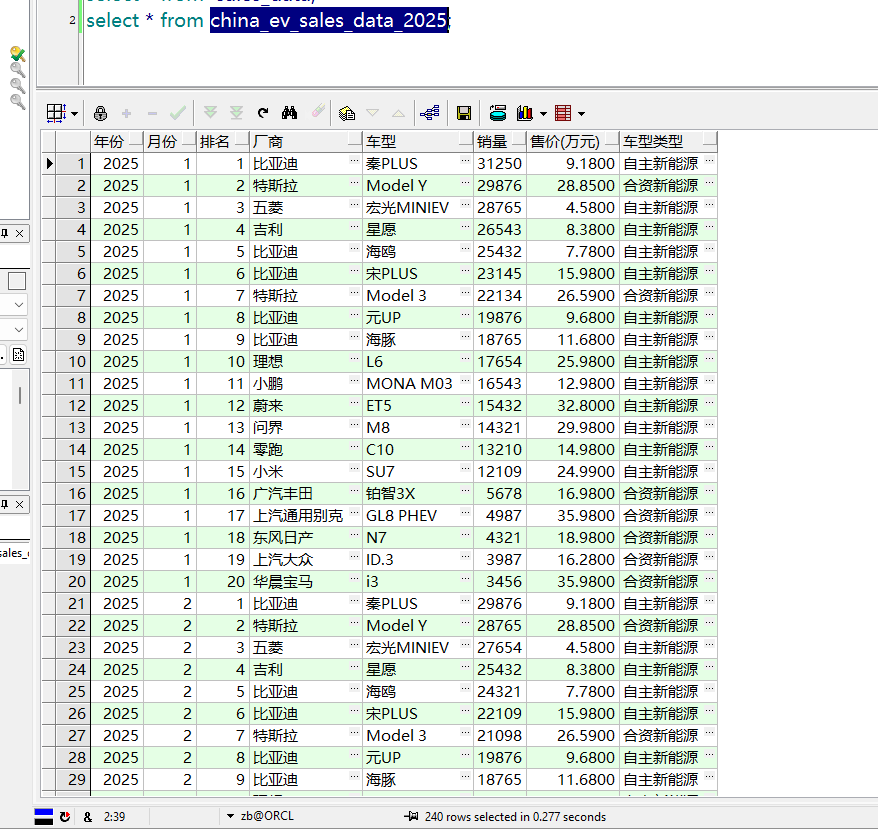

In [ ]:
spark.stop()

: 